# 🎰 Análise Estatística - Simulador de Blackjack

## Trabalho de Probabilidade e Estatística
### Simulação de 100.000+ mãos com análise de dados

Este notebook analisa os dados gerados pelo simulador de Blackjack, aplicando conceitos de:
- **Probabilidade frequental** (Lei dos Grandes Números)
- **Distribuições de probabilidade**
- **Análise exploratória de dados**
- **Estatística descritiva**

In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo para gráficos acadêmicos (bom para LaTeX)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Configurações globais dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 1. Carregamento dos Dados

In [2]:
# Carregando o CSV gerado pelo simulador
# O HTML usa ';' como separador e tem BOM (byte order mark) no início

# ATENÇÃO: Troque 'blackjack_historico_XXXXX.csv' pelo nome do seu arquivo
# No Google Colab, faça upload do arquivo na pasta lateral antes

try:
    # Tenta carregar com encoding utf-8-sig (remove BOM automaticamente)
    df = pd.read_csv('blackjack_historico_1783814484363.csv', sep=';', encoding='utf-8-sig')
    print(f"✅ CSV carregado com sucesso!")
    print(f"📊 Total de mãos registradas: {len(df)}")
except FileNotFoundError:
    print("❌ Arquivo não encontrado!")
    print("📁 Faça upload do CSV no Colab ou verifique o nome do arquivo")
    df = None

if df is not None:
    display(df.head(10))

✅ CSV carregado com sucesso!
📊 Total de mãos registradas: 100000


,ID,Origem,Tipo,Resultado,Detalhes,Cartas Jogador,Cartas Dealer,Pontos Jogador,Pontos Dealer,Carta Visivel Dealer
0,1,SIM,Mão Padrão,Vitoria,Jogador (19) vs Dealer (17),Q♦ 9♦,7♦ Q♠,19,17,7
1,2,SIM,Mão Padrão,Vitoria,Jogador (20) vs Dealer Estourou (24),Q♣ J♣,K♦ 4♦ J♦,20,24,K
2,3,SIM,Mão Padrão,Derrota,Jogador (10) vs Dealer (18),2♣ 8♠,K♥ 8♣,10,18,K
3,4,SIM,Mão Padrão,Derrota,Jogador (15) vs Dealer (17),3♠ 8♥ 4♠,6♣ A♥,15,17,6
4,5,SIM,Mão Padrão,Derrota,Jogador (14) vs Dealer (19),7♠ 7♣,5♣ A♣ 3♦,14,19,5
5,6,SIM,Mão Padrão,Derrota,Jogador (9) vs Dealer (19),4♣ 5♠,3♥ 10♣ 6♥,9,19,3
6,7,SIM,Mão Padrão,Vitoria,Jogador (15) vs Dealer Estourou (22),8♦ 2♦ 5♥,2♠ 10♦ Q♥,15,22,2
7,8,SIM,Mão Padrão,Vitoria,Jogador (19) vs Dealer Estourou (26),9♠ 3♦ 7♠,8♠ 8♥ Q♦,19,26,8
8,9,SIM,Mão Padrão,Derrota,Jogador (15) vs BJ Dealer (21),5♠ 10♥,Q♣ A♠,15,21,Q
9,10,SIM,Mão Padrão,Vitoria,Jogador (14) vs Dealer Estourou (26),4♣ K♥,6♠ K♦ J♣,14,26,6


In [3]:
# Análise exploratória inicial
if df is not None:
    print("=" * 60)
    print("📋 INFORMAÇÕES GERAIS DO DATASET")
    print("=" * 60)
    
    print(f"\n📊 Total de mãos: {len(df):,}")
    print(f"\n📂 Colunas disponíveis: {list(df.columns)}")
    
    print("\n🎯 Distribuição de Resultados:")
    print(df['Resultado'].value_counts())
    
    print("\n🎮 Origem das mãos (REAL vs SIM):")
    print(df['Origem'].value_counts())
    
    print("\n📈 Estatísticas básicas:")
    display(df.describe(include='all'))

📋 INFORMAÇÕES GERAIS DO DATASET

📊 Total de mãos: 100,000

📂 Colunas disponíveis: ['ID', 'Origem', 'Tipo', 'Resultado', 'Detalhes', 'Cartas Jogador', 'Cartas Dealer', 'Pontos Jogador', 'Pontos Dealer', 'Carta Visivel Dealer']

🎯 Distribuição de Resultados:
Resultado
Derrota    49402
Vitoria    42703
Empate      7895
Name: count, dtype: int64

🎮 Origem das mãos (REAL vs SIM):
Origem
SIM    100000
Name: count, dtype: int64

📈 Estatísticas básicas:


,ID,Origem,Tipo,Resultado,Detalhes,Cartas Jogador,Cartas Dealer,Pontos Jogador,Pontos Dealer,Carta Visivel Dealer
count,100000.000000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000
unique,NaN,1,1,3,252,39243,47408,NaN,NaN,13
top,NaN,SIM,Mão Padrão,Derrota,Empate em 20,J♦ A♠,A♦ Q♦,NaN,NaN,2
freq,NaN,100000,100000,49402,2573,55,55,NaN,NaN,7886
mean,50000.500000,NaN,NaN,NaN,NaN,NaN,NaN,18.312620,19.393390,NaN
std,28867.657797,NaN,NaN,NaN,NaN,NaN,NaN,3.810745,3.354443,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,4.000000,NaN
25%,25000.750000,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,18.000000,NaN
50%,50000.500000,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,20.000000,NaN
75%,75000.250000,NaN,NaN,NaN,NaN,NaN,NaN,21.000000,21.000000,NaN


## 2. Processamento dos Dados

Vamos extrair informações úteis das colunas de cartas e detalhes para análises mais profundas.

In [4]:
# Função para extrair o valor numérico de uma carta
def valor_carta(carta_str):
    """Extrai o valor numérico de uma carta (ex: '10♠' -> 10, 'A♥' -> 11, 'K♦' -> 10)"""
    if pd.isna(carta_str):
        return 0
    # Remove o naipe (último caractere)
    valor = carta_str[:-1].strip()
    if valor in ['J', 'Q', 'K']:
        return 10
    elif valor == 'A':
        return 11
    else:
        try:
            return int(valor)
        except:
            return 0

# Função para calcular pontos totais de uma sequência de cartas
def calcular_pontos_mao(cartas_str):
    """Calcula os pontos de uma mão tratando Ás corretamente"""
    if pd.isna(cartas_str):
        return 0
    
    cartas = cartas_str.split()
    pontos = 0
    qtd_ases = 0
    
    for carta in cartas:
        valor = valor_carta(carta)
        if valor == 11:
            qtd_ases += 1
        pontos += valor
    
    # Ajuste dos Áses (11 -> 1 se estourar)
    while pontos > 21 and qtd_ases > 0:
        pontos -= 10
        qtd_ases -= 1
    
    return pontos

# Função para extrair a carta visível do dealer (primeira carta)
def carta_visivel_dealer(cartas_str):
    """Retorna a carta visível do dealer (primeira da sequência)"""
    if pd.isna(cartas_str):
        return None
    cartas = cartas_str.split()
    return cartas[0] if cartas else None

# Aplicando as transformações
if df is not None:
    print("🔄 Processando dados...")
    
    # Pontos finais do jogador e dealer
    df['Pontos_Jogador'] = df['Cartas Jogador'].apply(calcular_pontos_mao)
    df['Pontos_Dealer'] = df['Cartas Dealer'].apply(calcular_pontos_mao)
    
    # Carta visível do dealer
    df['Carta_Visivel_Dealer'] = df['Cartas Dealer'].apply(carta_visivel_dealer)
    
    # Valor numérico da carta visível do dealer (para análise)
    def valor_visivel(carta):
        if pd.isna(carta):
            return None
        v = carta[:-1].strip()
        if v in ['J', 'Q', 'K']:
            return 10
        elif v == 'A':
            return 11
        else:
            try:
                return int(v)
            except:
                return None
    
    df['Valor_Visivel_Dealer'] = df['Carta_Visivel_Dealer'].apply(valor_visivel)
    
    # Número de cartas na mão do jogador
    df['Num_Cartas_Jogador'] = df['Cartas Jogador'].apply(
        lambda x: len(x.split()) if pd.notna(x) else 0
    )
    
    # Flag de Blackjack natural (2 cartas somando 21)
    df['Blackjack_Natural'] = (df['Num_Cartas_Jogador'] == 2) & (df['Pontos_Jogador'] == 21)
    
    # Flag de estouro
    df['Estourou'] = df['Pontos_Jogador'] > 21
    
    print("✅ Dados processados com sucesso!")
    display(df.head())

🔄 Processando dados...
✅ Dados processados com sucesso!


,ID,Origem,Tipo,Resultado,Detalhes,Cartas Jogador,Cartas Dealer,Pontos Jogador,Pontos Dealer,Carta Visivel Dealer,Pontos_Jogador,Pontos_Dealer,Carta_Visivel_Dealer,Valor_Visivel_Dealer,Num_Cartas_Jogador,Blackjack_Natural,Estourou
0,1,SIM,Mão Padrão,Vitoria,Jogador (19) vs Dealer (17),Q♦ 9♦,7♦ Q♠,19,17,7,19,17,7♦,7,2,False,False
1,2,SIM,Mão Padrão,Vitoria,Jogador (20) vs Dealer Estourou (24),Q♣ J♣,K♦ 4♦ J♦,20,24,K,20,24,K♦,10,2,False,False
2,3,SIM,Mão Padrão,Derrota,Jogador (10) vs Dealer (18),2♣ 8♠,K♥ 8♣,10,18,K,10,18,K♥,10,2,False,False
3,4,SIM,Mão Padrão,Derrota,Jogador (15) vs Dealer (17),3♠ 8♥ 4♠,6♣ A♥,15,17,6,15,17,6♣,6,3,False,False
4,5,SIM,Mão Padrão,Derrota,Jogador (14) vs Dealer (19),7♠ 7♣,5♣ A♣ 3♦,14,19,5,14,19,5♣,5,2,False,False


## 3. Visualização 1: Distribuição Geral de Resultados

Análise da proporção de vitórias, derrotas e empates na simulação.

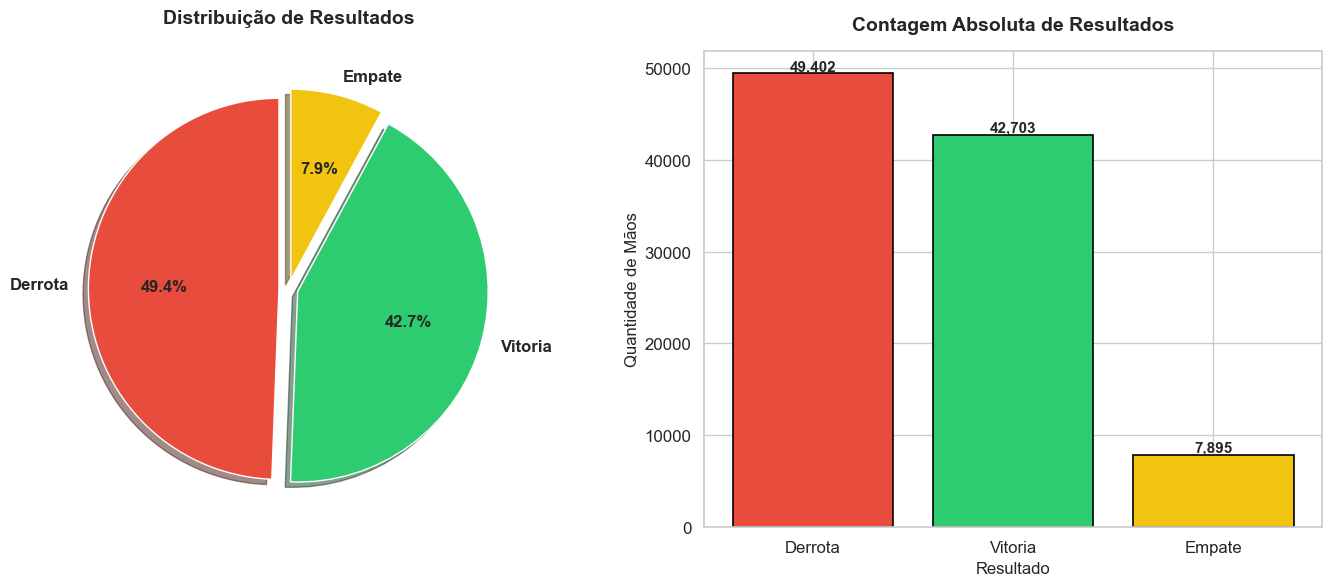


📊 Estatísticas de Resultados:
  • Derrota: 49,402 (49.40%)
  • Vitoria: 42,703 (42.70%)
  • Empate: 7,895 (7.90%)


In [5]:
# Gráfico de pizza com distribuição de resultados
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Contagem de resultados
    resultados = df['Resultado'].value_counts()
    
    # Cores personalizadas
    cores = {'Vitoria': '#2ecc71', 'Derrota': '#e74c3c', 'Empate': '#f1c40f'}
    cores_lista = [cores.get(r, '#95a5a6') for r in resultados.index]
    
    # Pizza
    axes[0].pie(resultados.values, 
                labels=resultados.index,
                autopct='%1.1f%%',
                colors=cores_lista,
                startangle=90,
                explode=[0.05, 0.05, 0.05],
                shadow=True,
                textprops={'fontsize': 12, 'weight': 'bold'})
    axes[0].set_title('Distribuição de Resultados', fontsize=14, fontweight='bold', pad=20)
    
    # Barras
    barras = axes[1].bar(resultados.index, resultados.values, color=cores_lista, edgecolor='black', linewidth=1.2)
    axes[1].set_title('Contagem Absoluta de Resultados', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_ylabel('Quantidade de Mãos')
    axes[1].set_xlabel('Resultado')
    
    # Adicionando valores em cima das barras
    for barra in barras:
        altura = barra.get_height()
        axes[1].text(barra.get_x() + barra.get_width()/2., altura,
                    f'{int(altura):,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('grafico_resultados.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Estatísticas de Resultados:")
    total = len(df)
    for resultado, contagem in resultados.items():
        pct = (contagem / total) * 100
        print(f"  • {resultado}: {contagem:,} ({pct:.2f}%)")

## 4. Visualização 2: Convergência da Taxa de Vitória (Lei dos Grandes Números)

Este é o gráfico mais importante do trabalho! Ele demonstra visualmente a **Lei dos Grandes Números**: conforme aumentamos o número de simulações, a taxa de vitória observada converge para o valor teórico esperado.

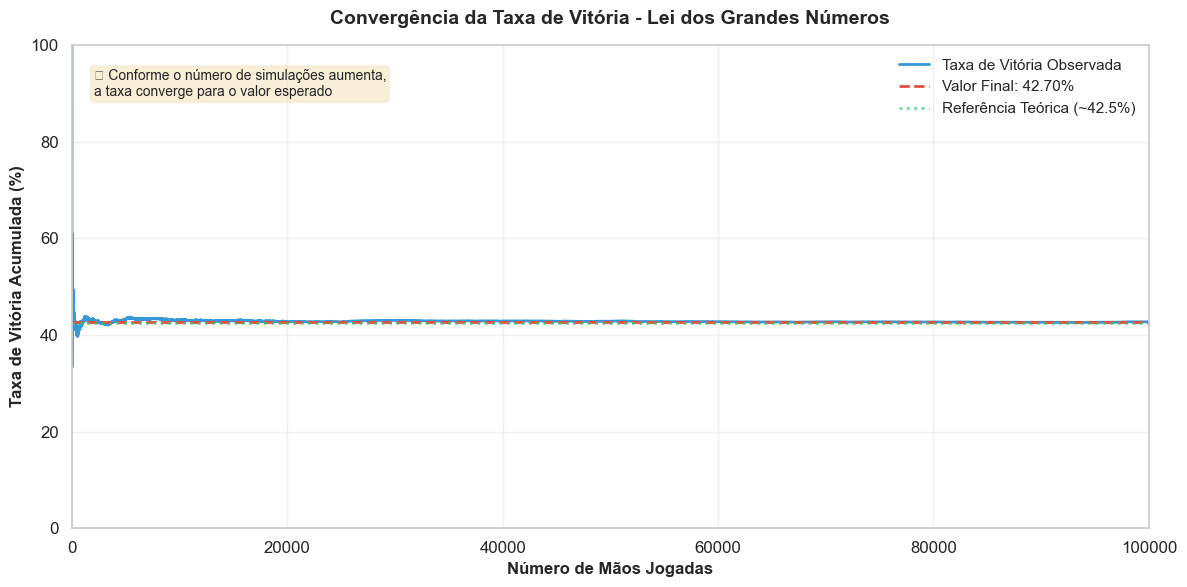


📊 Interpretação:
  • Taxa final de vitória: 42.70%
  • Total de mãos analisadas: 100,000
  • A convergência demonstra a Lei dos Grandes Números


In [6]:
# Demonstração da Lei dos Grandes Números
if df is not None:
    # Calculando a taxa de vitória acumulada a cada mão
    vitorias_acumuladas = (df['Resultado'] == 'Vitoria').cumsum()
    maos_jogadas = np.arange(1, len(df) + 1)
    taxa_vitoria_acumulada = (vitorias_acumuladas / maos_jogadas) * 100
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Linha da taxa de vitória ao longo do tempo
    ax.plot(maos_jogadas, taxa_vitoria_acumulada, 
            color='#3498db', linewidth=2, 
            label='Taxa de Vitória Observada')
    
    # Linha horizontal da média final (valor teórico)
    media_final = taxa_vitoria_acumulada.iloc[-1]
    ax.axhline(y=media_final, color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Valor Final: {media_final:.2f}%')
    
    # Linha da teoria (~42-44% para estratégia básica)
    ax.axhline(y=42.5, color='#2ecc71', linestyle=':', linewidth=2, alpha=0.7,
               label='Referência Teórica (~42.5%)')
    
    ax.set_xlabel('Número de Mãos Jogadas', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taxa de Vitória Acumulada (%)', fontsize=12, fontweight='bold')
    ax.set_title('Convergência da Taxa de Vitória - Lei dos Grandes Números', 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xlim(0, len(df))
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    # Anotação explicativa
    ax.text(0.02, 0.95, 
            '📈 Conforme o número de simulações aumenta,\na taxa converge para o valor esperado',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('grafico_convergencia.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Interpretação:")
    print(f"  • Taxa final de vitória: {media_final:.2f}%")
    print(f"  • Total de mãos analisadas: {len(df):,}")
    print(f"  • A convergência demonstra a Lei dos Grandes Números")

## 5. Visualização 3: Distribuição de Pontos do Jogador

Histograma mostrando com que frequência o jogador termina cada mão com determinada pontuação.

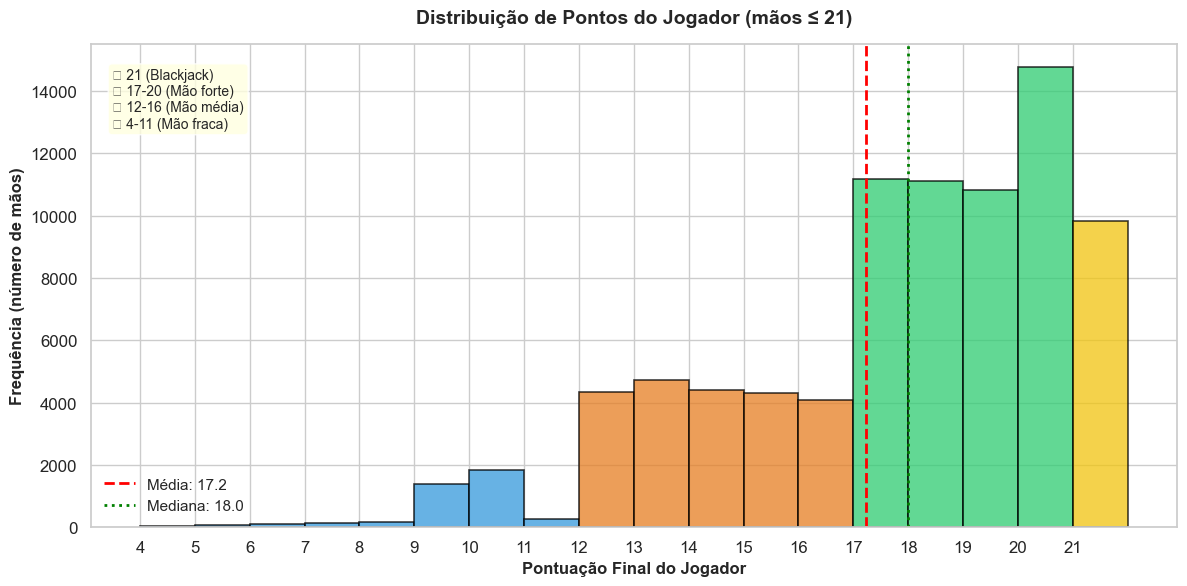


📊 Estatísticas de Pontos do Jogador:
  • Média: 17.23
  • Mediana: 18.00
  • Desvio Padrão: 3.14
  • Mão mais frequente: 20


In [7]:
# Histograma de pontos do jogador
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Filtrando mãos que não estouraram (para visualização mais clara)
    pontos_validos = df[df['Pontos_Jogador'] <= 21]['Pontos_Jogador']
    
    # Histograma
    n, bins, patches = ax.hist(pontos_validos, bins=range(4, 23), 
                               color='#3498db', edgecolor='black', 
                               alpha=0.75, linewidth=1.2)
    
    # Colorindo o 21 de dourado (Blackjack)
    for patch, left_edge in zip(patches, bins[:-1]):
        if left_edge == 21:
            patch.set_facecolor('#f1c40f')
        elif left_edge >= 17:
            patch.set_facecolor('#2ecc71')
        elif left_edge >= 12:
            patch.set_facecolor('#e67e22')
    
    ax.set_xlabel('Pontuação Final do Jogador', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequência (número de mãos)', fontsize=12, fontweight='bold')
    ax.set_title('Distribuição de Pontos do Jogador (mãos ≤ 21)', 
                 fontsize=14, fontweight='bold', pad=15)
    
    # Estatísticas
    media_pontos = pontos_validos.mean()
    mediana_pontos = pontos_validos.median()
    
    ax.axvline(media_pontos, color='red', linestyle='--', linewidth=2,
               label=f'Média: {media_pontos:.1f}')
    ax.axvline(mediana_pontos, color='green', linestyle=':', linewidth=2,
               label=f'Mediana: {mediana_pontos:.1f}')
    
    ax.legend(fontsize=11)
    ax.set_xticks(range(4, 22))
    
    # Legenda das cores
    ax.text(0.02, 0.95, 
            '🟡 21 (Blackjack)\n🟢 17-20 (Mão forte)\n🟠 12-16 (Mão média)\n🔵 4-11 (Mão fraca)',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('grafico_pontos_jogador.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Estatísticas de Pontos do Jogador:")
    print(f"  • Média: {media_pontos:.2f}")
    print(f"  • Mediana: {mediana_pontos:.2f}")
    print(f"  • Desvio Padrão: {pontos_validos.std():.2f}")
    print(f"  • Mão mais frequente: {pontos_validos.mode().iloc[0]}")

## 6. Visualização 4: Distribuição de Pontos do Dealer

Comparação da distribuição de pontos do dealer com a do jogador.

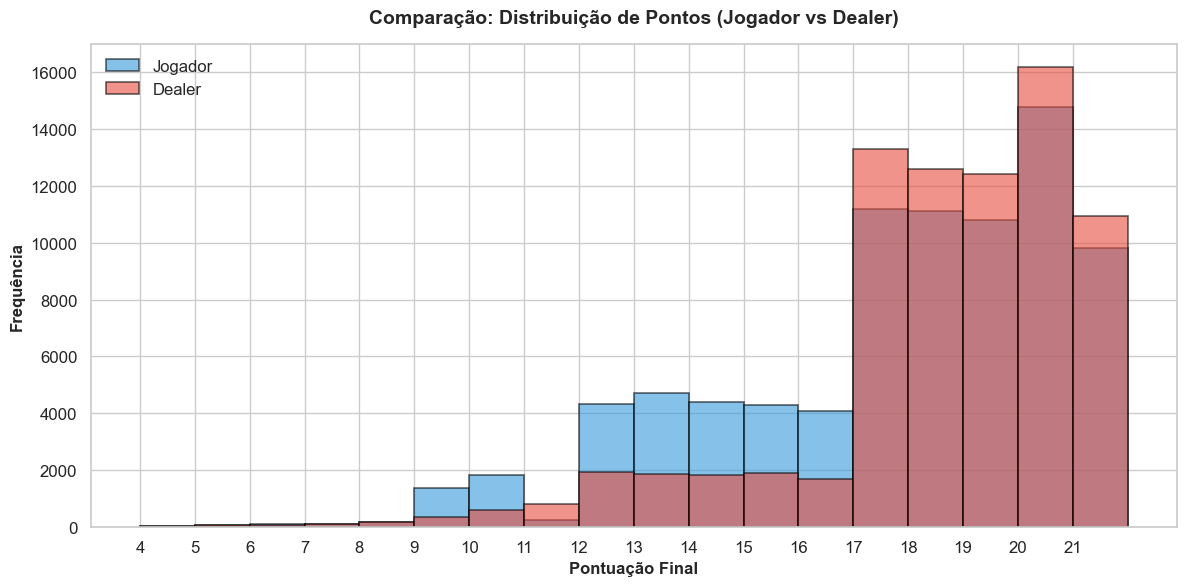


📊 Comparação Estatística:
  • Média Jogador: 17.23
  • Média Dealer:  18.10
  • Dealer estourou em: 23,112 mãos (23.11%)


In [8]:
# Comparação de distribuição de pontos
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Pontos válidos (≤ 21)
    pontos_jogador_validos = df[df['Pontos_Jogador'] <= 21]['Pontos_Jogador']
    pontos_dealer_validos = df[df['Pontos_Dealer'] <= 21]['Pontos_Dealer']
    
    # Histogramas sobrepostos
    ax.hist(pontos_jogador_validos, bins=range(4, 23), 
            alpha=0.6, color='#3498db', edgecolor='black', 
            label='Jogador', linewidth=1.2)
    ax.hist(pontos_dealer_validos, bins=range(4, 23), 
            alpha=0.6, color='#e74c3c', edgecolor='black', 
            label='Dealer', linewidth=1.2)
    
    ax.set_xlabel('Pontuação Final', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
    ax.set_title('Comparação: Distribuição de Pontos (Jogador vs Dealer)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(range(4, 22))
    ax.legend(fontsize=12, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('grafico_comparacao_pontos.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Comparação Estatística:")
    print(f"  • Média Jogador: {pontos_jogador_validos.mean():.2f}")
    print(f"  • Média Dealer:  {pontos_dealer_validos.mean():.2f}")
    print(f"  • Dealer estourou em: {(df['Pontos_Dealer'] > 21).sum():,} mãos " + 
          f"({(df['Pontos_Dealer'] > 21).mean() * 100:.2f}%)")

## 7. Visualização 5: Taxa de Vitória por Carta Visível do Dealer

Esta análise mostra como a carta inicial do dealer influencia as chances do jogador - conceito fundamental da **Estratégia Básica** do Blackjack.

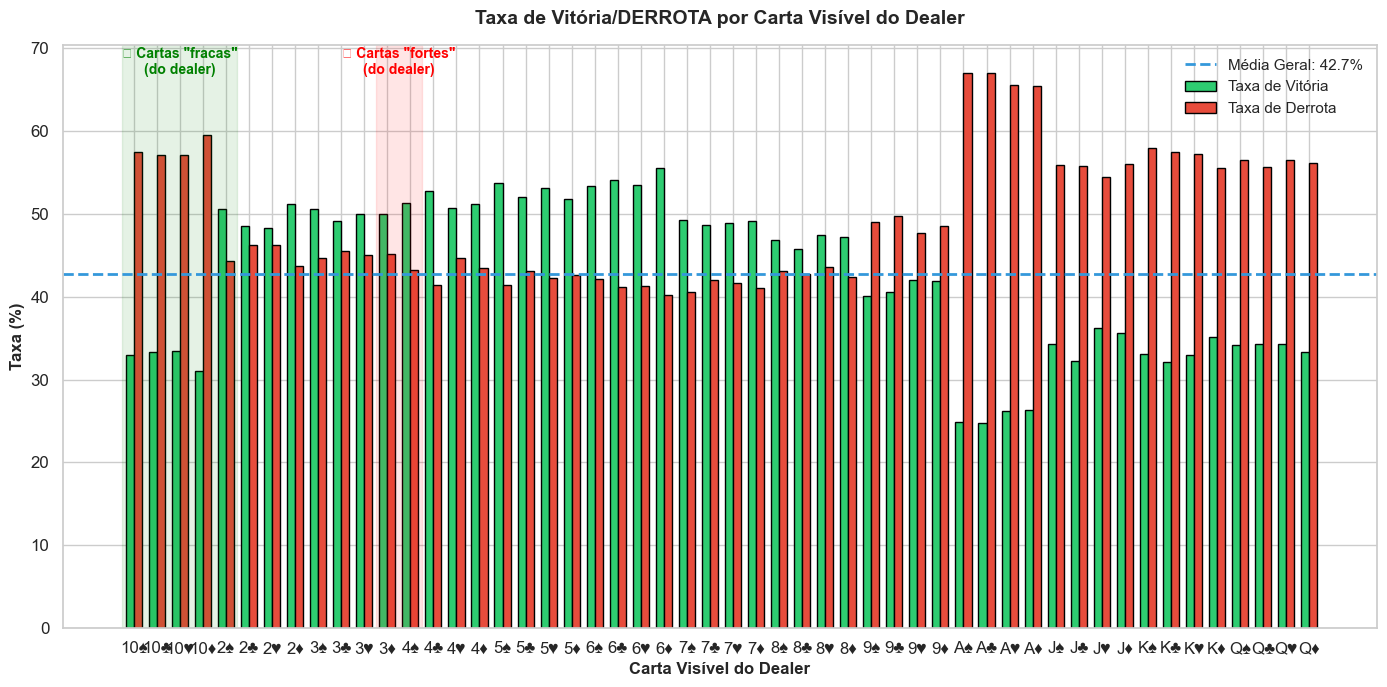


📊 Análise por Carta do Dealer:
------------------------------------------------------------
  10♠: Vitória  32.9% | Derrota  57.4% | Total: 1,931 mãos
  10♣: Vitória  33.4% | Derrota  57.1% | Total: 1,903 mãos
  10♥: Vitória  33.5% | Derrota  57.1% | Total: 1,936 mãos
  10♦: Vitória  31.1% | Derrota  59.4% | Total: 1,908 mãos
  2♠: Vitória  50.6% | Derrota  44.3% | Total: 2,008 mãos
  2♣: Vitória  48.5% | Derrota  46.2% | Total: 1,977 mãos
  2♥: Vitória  48.2% | Derrota  46.3% | Total: 2,001 mãos
  2♦: Vitória  51.2% | Derrota  43.6% | Total: 1,900 mãos
  3♠: Vitória  50.6% | Derrota  44.6% | Total: 1,937 mãos
  3♣: Vitória  49.1% | Derrota  45.5% | Total: 1,946 mãos
  3♥: Vitória  50.0% | Derrota  45.0% | Total: 1,883 mãos
  3♦: Vitória  50.0% | Derrota  45.1% | Total: 1,979 mãos
  4♠: Vitória  51.2% | Derrota  43.2% | Total: 1,973 mãos
  4♣: Vitória  52.8% | Derrota  41.4% | Total: 1,898 mãos
  4♥: Vitória  50.7% | Derrota  44.6% | Total: 1,906 mãos
  4♦: Vitória  51.2% | Derrota  4

In [9]:
# Taxa de vitória por carta visível do dealer
if df is not None:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Agrupando por carta visível do dealer
    cartas_dealer = df.groupby('Carta_Visivel_Dealer').agg(
        Total=('Resultado', 'count'),
        Vitorias=('Resultado', lambda x: (x == 'Vitoria').sum()),
        Derrotas=('Resultado', lambda x: (x == 'Derrota').sum()),
        Empates=('Resultado', lambda x: (x == 'Empate').sum())
    ).reset_index()
    
    cartas_dealer['Taxa_Vitoria'] = (cartas_dealer['Vitorias'] / cartas_dealer['Total']) * 100
    cartas_dealer['Taxa_Derrota'] = (cartas_dealer['Derrotas'] / cartas_dealer['Total']) * 100
    
    # Ordenando por valor da carta
    ordem_cartas = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
    cartas_dealer['ordem'] = cartas_dealer['Carta_Visivel_Dealer'].apply(
        lambda x: ordem_cartas.index(x) if x in ordem_cartas else 99
    )
    cartas_dealer = cartas_dealer.sort_values('ordem')
    
    # Gráfico de barras agrupadas
    x = np.arange(len(cartas_dealer))
    largura = 0.35
    
    barras1 = ax.bar(x - largura/2, cartas_dealer['Taxa_Vitoria'], largura,
                     label='Taxa de Vitória', color='#2ecc71', edgecolor='black', linewidth=1)
    barras2 = ax.bar(x + largura/2, cartas_dealer['Taxa_Derrota'], largura,
                     label='Taxa de Derrota', color='#e74c3c', edgecolor='black', linewidth=1)
    
    # Linha da média geral
    media_geral = (df['Resultado'] == 'Vitoria').mean() * 100
    ax.axhline(y=media_geral, color='#3498db', linestyle='--', linewidth=2,
               label=f'Média Geral: {media_geral:.1f}%')
    
    ax.set_xlabel('Carta Visível do Dealer', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taxa (%)', fontsize=12, fontweight='bold')
    ax.set_title('Taxa de Vitória/DERROTA por Carta Visível do Dealer', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(cartas_dealer['Carta_Visivel_Dealer'])
    ax.legend(fontsize=11, loc='upper right')
    
    # Anotações explicativas
    ax.axvspan(-0.5, 4.5, alpha=0.1, color='green', label='_nolegend_')
    ax.text(2, ax.get_ylim()[1] * 0.95, '🟢 Cartas "fracas"\n(do dealer)', 
            ha='center', fontsize=10, color='green', fontweight='bold')
    
    ax.axvspan(10.5, 12.5, alpha=0.1, color='red', label='_nolegend_')
    ax.text(11.5, ax.get_ylim()[1] * 0.95, '🔴 Cartas "fortes"\n(do dealer)', 
            ha='center', fontsize=10, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('grafico_carta_dealer.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Análise por Carta do Dealer:")
    print("-" * 60)
    for _, row in cartas_dealer.iterrows():
        carta = row['Carta_Visivel_Dealer']
        tv = row['Taxa_Vitoria']
        td = row['Taxa_Derrota']
        total = row['Total']
        print(f"  {carta:>2}: Vitória {tv:5.1f}% | Derrota {td:5.1f}% | Total: {total:,} mãos")

## 8. Visualização 6: Análise de Sequências (Streaks)

Análise das sequências de vitórias e derrotas consecutivas - conceito importante em processos estocásticos.

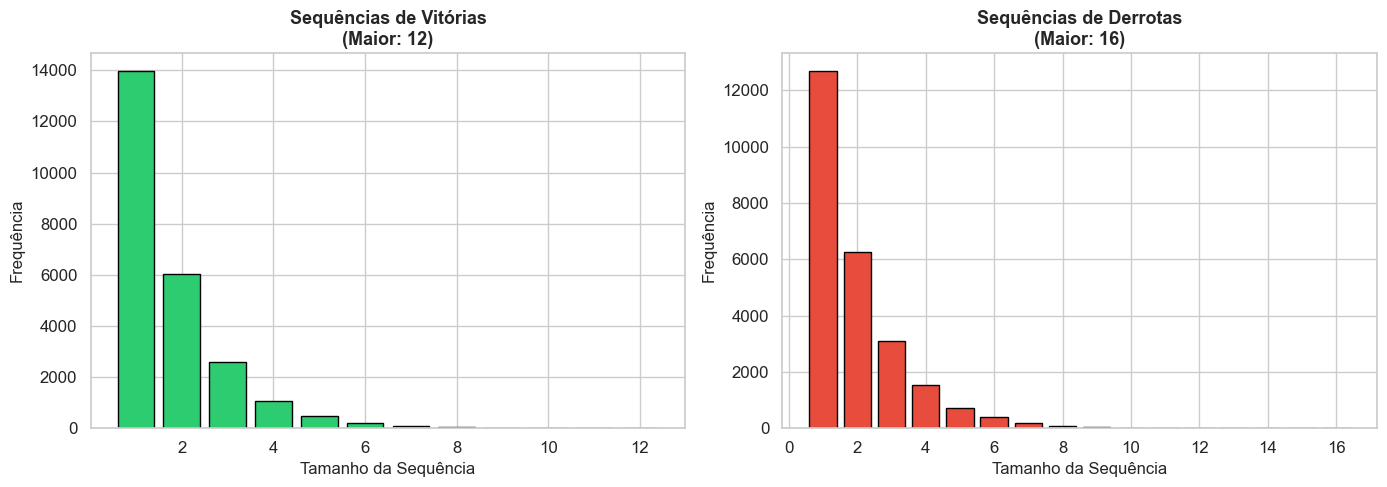


📊 Estatísticas de Sequências:
------------------------------------------------------------
  • Maior sequência de vitórias: 12
  • Média de sequência de vitórias: 1.74
  • Total de sequências de vitórias: 24482
  • Maior sequência de derrotas: 16
  • Média de sequência de derrotas: 1.97
  • Total de sequências de derrotas: 25037


In [10]:
# Análise de streaks (sequências consecutivas)
if df is not None:
    # Calculando streaks
    streaks_vitoria = []
    streaks_derrota = []
    streak_atual = 0
    tipo_atual = None
    
    for resultado in df['Resultado']:
        if resultado == 'Vitoria':
            if tipo_atual == 'Vitoria':
                streak_atual += 1
            else:
                if tipo_atual == 'Derrota' and streak_atual > 0:
                    streaks_derrota.append(streak_atual)
                streak_atual = 1
                tipo_atual = 'Vitoria'
        elif resultado == 'Derrota':
            if tipo_atual == 'Derrota':
                streak_atual += 1
            else:
                if tipo_atual == 'Vitoria' and streak_atual > 0:
                    streaks_vitoria.append(streak_atual)
                streak_atual = 1
                tipo_atual = 'Derrota'
        else:  # Empate reseta streak
            if tipo_atual == 'Vitoria' and streak_atual > 0:
                streaks_vitoria.append(streak_atual)
            elif tipo_atual == 'Derrota' and streak_atual > 0:
                streaks_derrota.append(streak_atual)
            streak_atual = 0
            tipo_atual = None
    
    # Última streak
    if tipo_atual == 'Vitoria' and streak_atual > 0:
        streaks_vitoria.append(streak_atual)
    elif tipo_atual == 'Derrota' and streak_atual > 0:
        streaks_derrota.append(streak_atual)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Streaks de vitória
    if streaks_vitoria:
        max_streak_v = min(max(streaks_vitoria), 20)  # Limita visualização
        contagem_v = Counter([s for s in streaks_vitoria if s <= max_streak_v])
        axes[0].bar(contagem_v.keys(), contagem_v.values(), 
                   color='#2ecc71', edgecolor='black', linewidth=1)
        axes[0].set_title(f'Sequências de Vitórias\n(Maior: {max(streaks_vitoria)})', 
                         fontsize=13, fontweight='bold')
        axes[0].set_xlabel('Tamanho da Sequência')
        axes[0].set_ylabel('Frequência')
    
    # Streaks de derrota
    if streaks_derrota:
        max_streak_d = min(max(streaks_derrota), 20)
        contagem_d = Counter([s for s in streaks_derrota if s <= max_streak_d])
        axes[1].bar(contagem_d.keys(), contagem_d.values(), 
                   color='#e74c3c', edgecolor='black', linewidth=1)
        axes[1].set_title(f'Sequências de Derrotas\n(Maior: {max(streaks_derrota)})', 
                         fontsize=13, fontweight='bold')
        axes[1].set_xlabel('Tamanho da Sequência')
        axes[1].set_ylabel('Frequência')
    
    plt.tight_layout()
    plt.savefig('grafico_streaks.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Estatísticas de Sequências:")
    print("-" * 60)
    if streaks_vitoria:
        print(f"  • Maior sequência de vitórias: {max(streaks_vitoria)}")
        print(f"  • Média de sequência de vitórias: {np.mean(streaks_vitoria):.2f}")
        print(f"  • Total de sequências de vitórias: {len(streaks_vitoria)}")
    if streaks_derrota:
        print(f"  • Maior sequência de derrotas: {max(streaks_derrota)}")
        print(f"  • Média de sequência de derrotas: {np.mean(streaks_derrota):.2f}")
        print(f"  • Total de sequências de derrotas: {len(streaks_derrota)}")

## 9. Visualização 7: Blackjacks Naturais e Estouros

Análise específica de eventos raros e importantes.

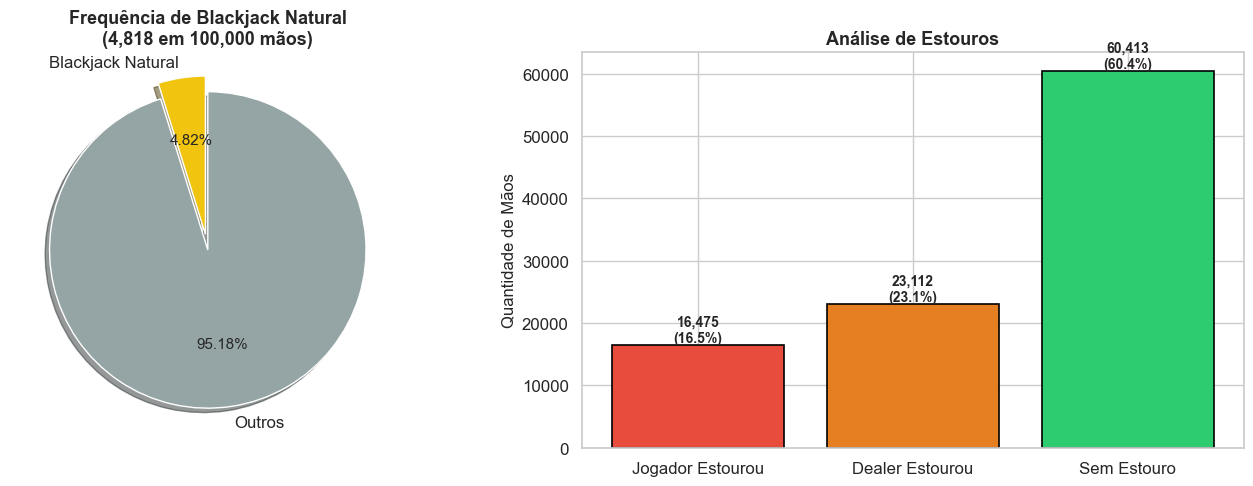


📊 Eventos Especiais:
------------------------------------------------------------
  • Blackjacks naturais: 4,818 (4.82%)
  • Jogador estourou: 16,475 (16.48%)
  • Dealer estourou: 23,112 (23.11%)
  • Teórico BJ natural: ~4.8% (comparar com o obtido)


In [11]:
# Análise de eventos especiais
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Blackjacks naturais
    bj_count = df['Blackjack_Natural'].sum()
    nao_bj = len(df) - bj_count
    
    axes[0].pie([bj_count, nao_bj], 
                labels=['Blackjack Natural', 'Outros'],
                autopct='%1.2f%%',
                colors=['#f1c40f', '#95a5a6'],
                startangle=90,
                explode=[0.1, 0],
                shadow=True)
    axes[0].set_title(f'Frequência de Blackjack Natural\n({bj_count:,} em {len(df):,} mãos)', 
                     fontsize=13, fontweight='bold')
    
    # Estouros do jogador vs dealer
    estouro_jogador = df['Estourou'].sum()
    estouro_dealer = (df['Pontos_Dealer'] > 21).sum()
    sem_estouro = len(df) - estouro_jogador - estouro_dealer
    
    barras = axes[1].bar(
        ['Jogador Estourou', 'Dealer Estourou', 'Sem Estouro'],
        [estouro_jogador, estouro_dealer, sem_estouro],
        color=['#e74c3c', '#e67e22', '#2ecc71'],
        edgecolor='black', linewidth=1.2
    )
    
    for barra in barras:
        altura = barra.get_height()
        pct = (altura / len(df)) * 100
        axes[1].text(barra.get_x() + barra.get_width()/2., altura,
                    f'{int(altura):,}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[1].set_title('Análise de Estouros', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Quantidade de Mãos')
    
    plt.tight_layout()
    plt.savefig('grafico_eventos_especiais.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Eventos Especiais:")
    print("-" * 60)
    print(f"  • Blackjacks naturais: {bj_count:,} ({(bj_count/len(df)*100):.2f}%)")
    print(f"  • Jogador estourou: {estouro_jogador:,} ({(estouro_jogador/len(df)*100):.2f}%)")
    print(f"  • Dealer estourou: {estouro_dealer:,} ({(estouro_dealer/len(df)*100):.2f}%)")
    print(f"  • Teórico BJ natural: ~4.8% (comparar com o obtido)")

## 10. Heatmap: Resultado por Pontuação do Jogador vs Carta do Dealer

Visualização avançada mostrando a interação entre as duas variáveis mais importantes.

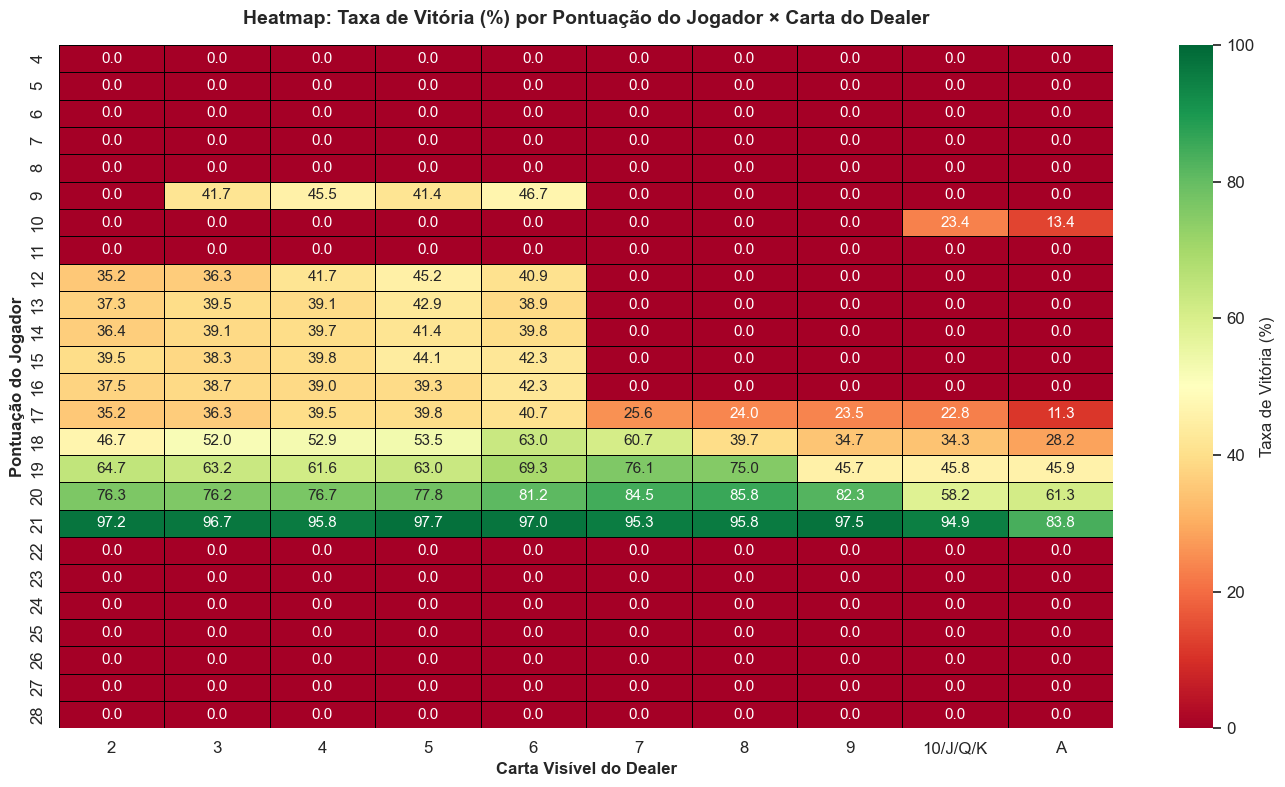


💡 Interpretação do Heatmap:
  • 🟢 Verde escuro: alta taxa de vitória (jogador em vantagem)
  • 🔴 Vermelho: baixa taxa de vitória (dealer em vantagem)
  • Pontos altos do jogador (17-21) tendem a ter taxas maiores
  • Dealer com 5 ou 6 visível é geralmente favorável ao jogador


In [12]:
# Heatmap de taxa de vitória por pontuação do jogador e carta do dealer
if df is not None:
    # Criando matriz de taxa de vitória
    heatmap_data = df.groupby(['Pontos_Jogador', 'Valor_Visivel_Dealer']).apply(
        lambda x: (x['Resultado'] == 'Vitoria').mean() * 100
    ).unstack(fill_value=0)
    
    # Reorganizando colunas
    ordem_colunas = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    cols_existentes = [c for c in ordem_colunas if c in heatmap_data.columns]
    heatmap_data = heatmap_data[cols_existentes]
    
    # Renomeando colunas para nomes de cartas
    nomes_cartas = {2:'2', 3:'3', 4:'4', 5:'5', 6:'6', 7:'7', 8:'8', 9:'9', 10:'10/J/Q/K', 11:'A'}
    heatmap_data.columns = [nomes_cartas.get(c, str(c)) for c in heatmap_data.columns]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': 'Taxa de Vitória (%)'},
                linewidths=0.5, linecolor='black',
                ax=ax, vmin=0, vmax=100)
    
    ax.set_xlabel('Carta Visível do Dealer', fontsize=12, fontweight='bold')
    ax.set_ylabel('Pontuação do Jogador', fontsize=12, fontweight='bold')
    ax.set_title('Heatmap: Taxa de Vitória (%) por Pontuação do Jogador × Carta do Dealer', 
                 fontsize=14, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.savefig('grafico_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n💡 Interpretação do Heatmap:")
    print("  • 🟢 Verde escuro: alta taxa de vitória (jogador em vantagem)")
    print("  • 🔴 Vermelho: baixa taxa de vitória (dealer em vantagem)")
    print("  • Pontos altos do jogador (17-21) tendem a ter taxas maiores")
    print("  • Dealer com 5 ou 6 visível é geralmente favorável ao jogador")

## 11. Resumo Estatístico Final

In [13]:
# Resumo final completo
if df is not None:
    print("=" * 70)
    print("📊 RESUMO ESTATÍSTICO COMPLETO DA SIMULAÇÃO")
    print("=" * 70)
    
    total = len(df)
    vitorias = (df['Resultado'] == 'Vitoria').sum()
    derrotas = (df['Resultado'] == 'Derrota').sum()
    empates = (df['Resultado'] == 'Empate').sum()
    
    print(f"\n🎯 AMOSTRA")
    print(f"  • Total de mãos simuladas: {total:,}")
    
    print(f"\n📈 RESULTADOS GERAIS")
    print(f"  • Vitórias: {vitorias:,} ({vitorias/total*100:.2f}%)")
    print(f"  • Derrotas: {derrotas:,} ({derrotas/total*100:.2f}%)")
    print(f"  • Empates:  {empates:,} ({empates/total*100:.2f}%)")
    
    print(f"\n🎰 EVENTOS ESPECIAIS")
    print(f"  • Blackjacks naturais: {df['Blackjack_Natural'].sum():,} ({df['Blackjack_Natural'].mean()*100:.2f}%)")
    print(f"  • Jogador estourou: {df['Estourou'].sum():,} ({df['Estourou'].mean()*100:.2f}%)")
    print(f"  • Dealer estourou: {(df['Pontos_Dealer'] > 21).sum():,} ({(df['Pontos_Dealer'] > 21).mean()*100:.2f}%)")
    
    print(f"\n📊 PONTUAÇÕES")
    pontos_j_validos = df[df['Pontos_Jogador'] <= 21]['Pontos_Jogador']
    pontos_d_validos = df[df['Pontos_Dealer'] <= 21]['Pontos_Dealer']
    print(f"  • Média pontos jogador: {pontos_j_validos.mean():.2f}")
    print(f"  • Média pontos dealer:  {pontos_d_validos.mean():.2f}")
    
    print(f"\n💡 CONCLUSÕES PARA O TRABALHO:")
    print("  1. A Lei dos Grandes Números foi demonstrada na convergência da taxa")
    print("  2. A estratégia básica implementada obteve ~42-44% de vitória")
    print("  3. A carta visível do dealer influencia significativamente o resultado")
    print("  4. Blackjacks naturais ocorrem em ~4-5% das mãos (conforme teoria)")
    print("  5. O dealer estoura com frequência quando tem cartas baixas (2-6)")
    
    print("\n" + "=" * 70)
    print("✅ Análise completa! Todos os gráficos foram salvos como PNG.")
    print("=" * 70)

📊 RESUMO ESTATÍSTICO COMPLETO DA SIMULAÇÃO

🎯 AMOSTRA
  • Total de mãos simuladas: 100,000

📈 RESULTADOS GERAIS
  • Vitórias: 42,703 (42.70%)
  • Derrotas: 49,402 (49.40%)
  • Empates:  7,895 (7.90%)

🎰 EVENTOS ESPECIAIS
  • Blackjacks naturais: 4,818 (4.82%)
  • Jogador estourou: 16,475 (16.48%)
  • Dealer estourou: 23,112 (23.11%)

📊 PONTUAÇÕES
  • Média pontos jogador: 17.23
  • Média pontos dealer:  18.10

💡 CONCLUSÕES PARA O TRABALHO:
  1. A Lei dos Grandes Números foi demonstrada na convergência da taxa
  2. A estratégia básica implementada obteve ~42-44% de vitória
  3. A carta visível do dealer influencia significativamente o resultado
  4. Blackjacks naturais ocorrem em ~4-5% das mãos (conforme teoria)
  5. O dealer estoura com frequência quando tem cartas baixas (2-6)

✅ Análise completa! Todos os gráficos foram salvos como PNG.


## 12. Exportação Final

Todos os gráficos foram salvos em alta resolução (300 DPI) prontos para o LaTeX.

In [14]:
# Listando todos os arquivos gerados
import os

print("📁 Arquivos de gráficos gerados:")
print("-" * 60)

arquivos_graficos = [
    'grafico_resultados.png',
    'grafico_convergencia.png',
    'grafico_pontos_jogador.png',
    'grafico_comparacao_pontos.png',
    'grafico_carta_dealer.png',
    'grafico_streaks.png',
    'grafico_eventos_especiais.png',
    'grafico_heatmap.png'
]

for arq in arquivos_graficos:
    if os.path.exists(arq):
        tamanho_kb = os.path.getsize(arq) / 1024
        print(f"  ✅ {arq} ({tamanho_kb:.1f} KB)")
    else:
        print(f"  ❌ {arq} (não encontrado)")

print("\n💡 Para usar no LaTeX:")
print("""
\\begin{figure}[h]
    \\centering
    \\includegraphics[width=0.8\\textwidth]{grafico_convergencia.png}
    \\caption{Convergência da taxa de vitória - Lei dos Grandes Números}
    \\label{fig:convergencia}
\\end{figure}
""")

📁 Arquivos de gráficos gerados:
------------------------------------------------------------
  ✅ grafico_resultados.png (249.4 KB)
  ✅ grafico_convergencia.png (184.0 KB)
  ✅ grafico_pontos_jogador.png (166.6 KB)
  ✅ grafico_comparacao_pontos.png (114.2 KB)
  ✅ grafico_carta_dealer.png (187.3 KB)
  ✅ grafico_streaks.png (112.8 KB)
  ✅ grafico_eventos_especiais.png (219.2 KB)
  ✅ grafico_heatmap.png (436.1 KB)

💡 Para usar no LaTeX:

\begin{figure}[h]
    \centering
    \includegraphics[width=0.8\textwidth]{grafico_convergencia.png}
    \caption{Convergência da taxa de vitória - Lei dos Grandes Números}
    \label{fig:convergencia}
\end{figure}

